In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.stats
import torch
from torch import tensor, Tensor

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import block_formats.quantisation as Q
import block_formats.analysis as A
import plot_utils

plot_utils.configure()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
UNDERLAY_ARGS = dict(zorder=0, lw=4, ls=(0, (4, 1)), ms=6, alpha=.5, marker="x")

def distribution_name(distribution: A.Distribution) -> str:
    if isinstance(distribution, A.StudentT):
        return f"t[$\\nu={distribution.df:.0f}$]"
    return type(distribution).__name__


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


## Optimal formats

### `normal_crd_example_4bit`

remote: Updating references: 100% (1/1)           


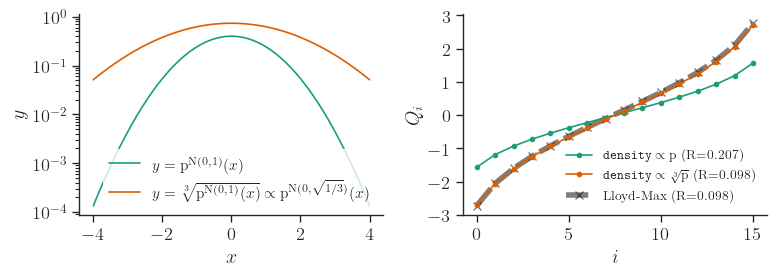

In [ ]:
bits = 4
samples = 2**20

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

x = torch.linspace(-4, 4, 1001)
ax0.plot(x, scipy.stats.norm.pdf(x), label=r"$y = \mathrm{p}^{\mathrm{N}(0, 1)}(x)$")
ax0.plot(x, scipy.stats.norm.pdf(x)**(1/3), label=r"$y = \sqrt[3]{\mathrm{p}^{\mathrm{N}(0, 1)}(x)} \propto \mathrm{p}^{\mathrm{N}(0, \sqrt{1/3})}(x)$")
ax0.set_yscale("log")
ax0.set_xlabel("$x$")
ax0.set_ylabel(r"$y$")
ax0.legend(loc="lower right")

dist = A.Normal()
X = dist.sample(samples, seed=1, device=DEVICE)
for fmt in [
        Q.crd_normal(bits, power=1),
        Q.crd_normal(bits),
        Q.lut_lloyd_max(dist.sample(samples, seed=2, device=DEVICE), bits, 1e-4),
    ]:
    name = {
        "CRD-N-RS{1}": r"$\texttt{density} \propto \mathrm{p}$",
        "CRD-N-RS": r"$\texttt{density} \propto \sqrt[3]{\mathrm{p}}$",
        "LM": r"Lloyd-Max",
    }[fmt.name]
    rmse = Q.rmse_norm(X, fmt.quantise(X)).item()
    ax1.plot(fmt.values, label=f"{name} (R={rmse:.3f})",
             **(dict(UNDERLAY_ARGS, c="k") if fmt.name == "LM" else dict(marker="o")))
ax1.set_yticks(list(range(-3, 3+1)))
ax1.set_xlabel("$i$")
ax1.set_ylabel("$Q_i$")
ax1.legend(loc="lower right", fontsize=9.5)

fig.tight_layout()
plot_utils.save("normal_crd_example_4bit")

### `crd_curves_4bit`

remote: Updating references: 100% (1/1)           


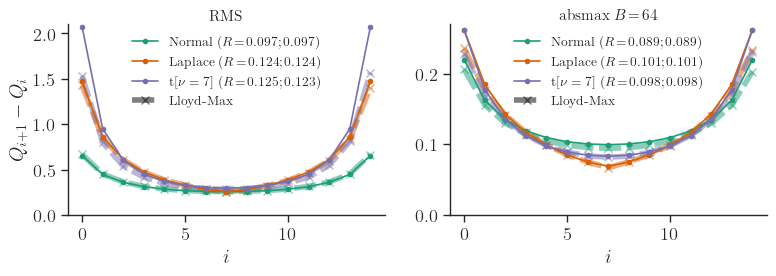

In [ ]:
bits = 4
samples = 2**22
t_df = 7
block_size = 64

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

def lut_diff(fmt: Q.LUTFormat) -> Tensor:
    return tensor(fmt.values[1:]) - tensor(fmt.values[:-1])

dists = [
    A.Normal(scale=1),
    A.Laplace(scale=2**-0.5),
    A.StudentT(df=t_df, scale=((t_df - 2) / t_df) ** .5),
]
for dist, color in zip(dists, plot_utils.PALETTE):
    torch.manual_seed(1)
    X = dist.sample(samples, seed=1, device=DEVICE)
    X_LM = dist.sample(samples, seed=2, device=DEVICE)
    assert 0.95 <= A.rms(X).item() <= 1.05

    crd_fmt = dist.rms_quantiser(bits)
    rmse = A.qrmse_norm(crd_fmt, X).item()
    lm_fmt = Q.lut_lloyd_max(X_LM, bits, 1e-4)
    lm_rmse = A.qrmse_norm(lm_fmt, X).item()

    ax0.plot(lut_diff(crd_fmt), label=f"{distribution_name(dist)} ($R\\!=\\!{rmse:.3f} ; {lm_rmse:.3f}$)", c=color, marker="o")
    ax0.plot(lut_diff(lm_fmt), c=color, **UNDERLAY_ARGS)

    block_crd_fmt = dist.absmax_quantiser(bits, block_size)
    block_rmse = A.qrmse_norm(Q.LinearScalingFormat(block_crd_fmt, Q.BFLOAT16, (block_size,), scaling="absmax"), X).item()
    block_lm_fmt = Q.lut_lloyd_max(A.block_normalise(X_LM, block_size), bits, 1e-4)
    block_lm_rmse = A.qrmse_norm(Q.LinearScalingFormat(block_lm_fmt, Q.BFLOAT16, (block_size,), scaling="absmax"), X).item()

    ax1.plot(lut_diff(block_crd_fmt), label=f"{distribution_name(dist)} ($R\\!=\\!{block_rmse:.3f} ; {block_lm_rmse:.3f}$)", c=color, marker="o")
    ax1.plot(lut_diff(block_lm_fmt), c=color, **UNDERLAY_ARGS)

for ax in [ax0, ax1]:
    ax.set_xlabel("$i$")
    h, _ = ax.get_legend_handles_labels()
    h.append(matplotlib.lines.Line2D([], [], color="k", **UNDERLAY_ARGS, label="Lloyd-Max"))
    ax.legend(handles=h, loc="upper center", fontsize=9.5)

ax0.set_ylim((0, 2.1))
ax1.set_ylim((0, 0.27))

ax0.set_ylabel("$Q_{i+1} - Q_i$")
ax0.set_title("RMS", y=1, va="center")
ax1.set_title(f"absmax $B\\!=\\!{block_size}$", y=1, va="center")

fig.tight_layout()
plot_utils.save("crd_curves_4bit")

### `dist_absmax`

remote: Updating references: 100% (1/1)           


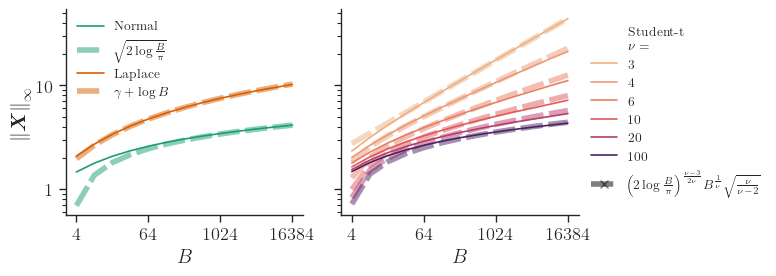

In [ ]:
samples = 2**22
B = tensor([2**n for n in range(2, 14+1)])

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3), sharey=True)

for color, dist in zip(plot_utils.PALETTE, [A.Normal(), A.Laplace()]):
    X = dist.sample(samples, seed=1, device=DEVICE)
    ax0.plot(B, [X.view(-1, Bi).abs().amax(-1).mean().item() for Bi in B], c=color, label=distribution_name(dist))
    if isinstance(dist, A.Normal):
        model = B.div(torch.pi).log().mul(2).sqrt()
        model_label = r"$\sqrt{2 \log \frac{B}{\pi}}$"
    if isinstance(dist, A.Laplace):
        model = B.log().add(0.57721566)
        model_label = r"$\gamma + \log B$"
    ax0.plot(B, model, **{**UNDERLAY_ARGS, "marker": None}, c=color, label=model_label)
ax0.legend(loc="upper left", fontsize=9.5)

t_dfs = tensor([3, 4, 6, 10, 20, 100])
for df, color in zip(t_dfs, plot_utils.SEQ_PALETTE(matplotlib.colors.LogNorm()(t_dfs))):
    X = A.StudentT(df.item()).sample(samples, seed=1, device=DEVICE)
    ax1.plot(B, [X.view(-1, Bi).abs().amax(-1).mean().item() for Bi in B], c=color, label=f"{df:.0f}")
    model = B.double().div(torch.pi).log().mul(2).pow((df-3)/2).mul(B).pow(1/df).mul((df/(df-2)).sqrt())
    ax1.plot(B, model, **{**UNDERLAY_ARGS, "marker": None}, c=color)
model_label = r"$\left(2 \log \frac{B}{\pi}\right)^{\frac{\nu-3}{2 \nu}}\! B^{\frac{1}{\nu}} \sqrt{\frac{\nu}{\nu - 2}}$"
h, _ = ax1.get_legend_handles_labels()
h.insert(0, matplotlib.lines.Line2D([], [], alpha=0, label="Student-t\n$\\nu=$"))
h.append(matplotlib.lines.Line2D([], [], color="k", **UNDERLAY_ARGS, label=model_label))
ax1.legend(handles=h, bbox_to_anchor=(1, 0.5), loc="center left", fontsize=9.5)

for ax in [ax0, ax1]:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks([4, 64, 1024, 16384])
    ax.xaxis.set_major_formatter("{x:.0f}")
    ax.yaxis.set_major_formatter("{x:.0f}")
    ax.set_xlabel("$B$")
ax0.set_ylabel(r"$\norm{\bm{X}}{\infty}$")

fig.tight_layout()
plot_utils.save("dist_absmax")

## Block vs independent formats on iid data

### `analysis_error_vs_bits`

remote: Updating references: 100% (1/1)           


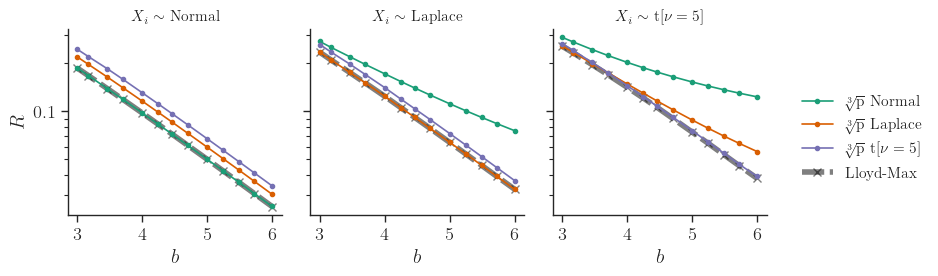

In [42]:
samples = 2**22
distributions = [A.Normal(), A.Laplace(), A.StudentT(df=5)]

fig, axs = plt.subplots(ncols=len(distributions), figsize=(8, 3), sharey=True)
for dist, ax in zip(distributions, axs):
    X = A.rms_normalise(dist.sample(samples, seed=1, device=DEVICE))

    methods = [
        (r"$\sqrt[3]{\mathrm{p}}$ " + distribution_name(dist), dist.rms_quantiser)
        for dist in distributions
    ]
    methods += [("Lloyd-Max", lambda b: Q.lut_lloyd_max(X, b, threshold=1e-4, init=("uniform", 3)))]
    for name, method in methods:
        fmts = [method(b) for b in torch.linspace(3, 6, 13)]
        ax.plot([fmt.count_bits(X.shape) / X.nelement() for fmt in fmts],
                [A.qrmse_norm(fmt, X).item() for fmt in fmts],
                label=name, **(dict(**UNDERLAY_ARGS, color="k") if name == "Lloyd-Max" else dict(marker="o")))

    ax.set_title(f"$X_i \\sim$ {distribution_name(dist)}")
    ax.set_yscale("log")
    ax.set_xlabel("$b$")
    ax.yaxis.set_major_formatter("{x:.1f}")
    ax.set_xticks(list(range(3, 6+1)))

axs[0].set_ylabel("$R$")
fig.legend(*axs[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout()
plot_utils.save("analysis_error_vs_bits")